In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install rasterio scikit-learn

import os
import numpy as np
import rasterio
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_PATH = "/content/drive/MyDrive/MARIDA"
PATCH_PATH = BASE_PATH + "/patches"
MODEL_PATH = "/content/drive/MyDrive/attention_unet_best.keras"

DEBRIS_CLASS = 1

In [ ]:
model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False   # important
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
def load_patch_by_name(name):
    name = name.replace(".tif","")
    full = "S2_" + name

    for scene in os.listdir(PATCH_PATH):
        sp = os.path.join(PATCH_PATH, scene)

        img_p  = os.path.join(sp, full+".tif")
        mask_p = os.path.join(sp, full+"_cl.tif")

        if os.path.exists(img_p) and os.path.exists(mask_p):
            try:
                with rasterio.open(img_p) as src:
                    img = src.read().astype(np.float32)
                with rasterio.open(mask_p) as src:
                    mask = src.read(1)
                return img, mask
            except:
                return None, None

    return None, None

In [ ]:
def compute_indices(img):
    img = img / 10000.0

    blue  = img[1]
    green = img[2]
    red   = img[3]
    nir   = img[7]
    swir1 = img[10]
    re2   = img[5]

    ndvi = (nir-red)/(nir+red+1e-6)
    ndwi = (green-nir)/(green+nir+1e-6)
    fdi  = nir - (re2 + (swir1-re2))

    f = np.stack([red,green,blue,nir,ndvi,ndwi,fdi], axis=-1)
    f = (f - np.mean(f)) / (np.std(f)+1e-6)

    return f.astype(np.float32)

In [ ]:
TH_SEG = 0.05
PIXEL_THRESHOLD = 2
MAX_THRESHOLD = 0.12

def classify_patch(img):
    pred = model.predict(img[np.newaxis,...], verbose=0)[0].squeeze()

    mask = pred > TH_SEG
    pixel_count = np.sum(mask)
    max_val = np.max(pred)

    if (pixel_count >= PIXEL_THRESHOLD and max_val > 0.08) or (max_val > MAX_THRESHOLD):
        return 1, pixel_count, max_val
    else:
        return 0, pixel_count, max_val

In [ ]:
all_patches = []

for scene in os.listdir(PATCH_PATH):
    for file in os.listdir(os.path.join(PATCH_PATH, scene)):
        if file.endswith(".tif") and not file.endswith("_cl.tif"):
            name = file.replace("S2_", "").replace(".tif", "")
            all_patches.append(name)

print("Total patches:", len(all_patches))

Total patches: 2779


In [ ]:
y_true = []
y_pred = []

for name in tqdm(all_patches):

    img, mask = load_patch_by_name(name)

    if img is None or mask is None:
        continue

    try:
        f = compute_indices(img)
    except:
        continue

    gt = 1 if np.sum(mask == DEBRIS_CLASS) > 0 else 0

    pred_cls, pixels, max_val = classify_patch(f)

    y_true.append(gt)
    y_pred.append(pred_cls)

100%|██████████| 2779/2779 [16:36<00:00,  2.79it/s]


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Confusion Matrix:
[[862 146]
 [131 242]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1008
           1       0.62      0.65      0.64       373

    accuracy                           0.80      1381
   macro avg       0.75      0.75      0.75      1381
weighted avg       0.80      0.80      0.80      1381



In [ ]:
name = all_patches[50]

img, mask = load_patch_by_name(name)

if img is not None:
    f = compute_indices(img)
    pred_cls, pixels, max_val = classify_patch(f)

    print("Predicted:", "Debris" if pred_cls else "No Debris")
    print("Pixel count:", pixels)
    print("Max value:", round(max_val,3))

    plt.imshow(f[:,:,0], cmap='gray')
    plt.title("Debris" if pred_cls else "No Debris")
    plt.axis('off')
    plt.show()

In [ ]:
start = 0
end = 100

for i in range(start, end):

    name = all_patches[i]
    img, _ = load_patch_by_name(name)

    if img is None:
        continue

    f = compute_indices(img)
    pred_cls, pixels, max_val = classify_patch(f)

    print(f"Image {i} →",
          "Debris" if pred_cls else "No Debris",
          "| Pixels:", pixels,
          "| Max:", round(max_val,3))

Image 0 → No Debris | Pixels: 0 | Max: 0.0
Image 2 → No Debris | Pixels: 0 | Max: 0.006
Image 3 → No Debris | Pixels: 0 | Max: 0.0
Image 4 → No Debris | Pixels: 0 | Max: 0.0
Image 5 → No Debris | Pixels: 0 | Max: 0.0
Image 8 → No Debris | Pixels: 0 | Max: 0.0
Image 11 → No Debris | Pixels: 0 | Max: 0.0
Image 12 → No Debris | Pixels: 0 | Max: 0.0
Image 14 → No Debris | Pixels: 0 | Max: 0.001
Image 19 → No Debris | Pixels: 0 | Max: 0.0
Image 20 → No Debris | Pixels: 0 | Max: 0.0
Image 21 → No Debris | Pixels: 0 | Max: 0.0
Image 22 → No Debris | Pixels: 0 | Max: 0.0
Image 24 → No Debris | Pixels: 0 | Max: 0.0
Image 27 → No Debris | Pixels: 0 | Max: 0.0
Image 30 → No Debris | Pixels: 0 | Max: 0.0
Image 31 → No Debris | Pixels: 0 | Max: 0.0
Image 36 → No Debris | Pixels: 0 | Max: 0.0
Image 37 → No Debris | Pixels: 0 | Max: 0.0
Image 39 → No Debris | Pixels: 0 | Max: 0.0
Image 40 → No Debris | Pixels: 0 | Max: 0.0
Image 45 → Debris | Pixels: 8 | Max: 1.0
Image 49 → No Debris | Pixels: 0 | Ma

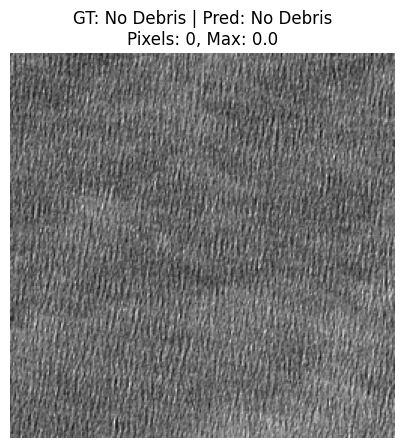

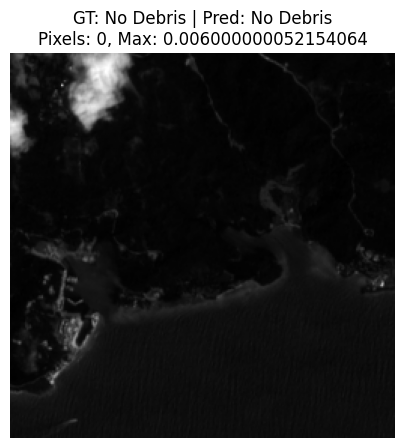

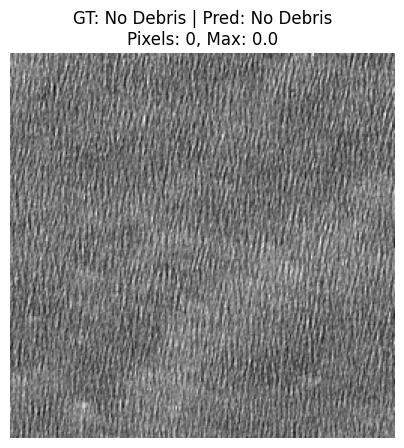

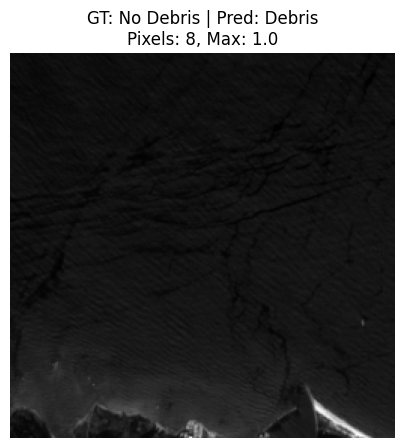

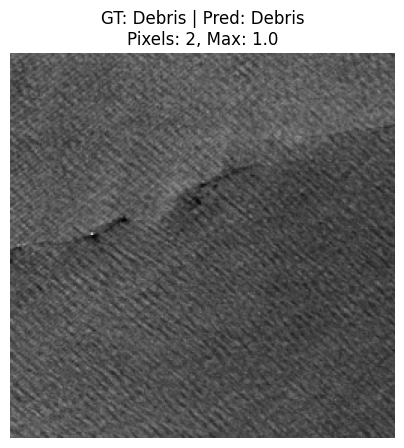

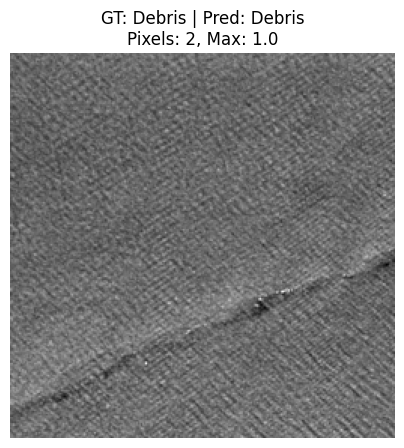

In [ ]:
debris_count = 0
nodebris_count = 0
i = 0

while (debris_count < 3 or nodebris_count < 3) and i < len(all_patches):

    name = all_patches[i]
    img, mask = load_patch_by_name(name)

    if img is None:
        i += 1
        continue

    f = compute_indices(img)
    pred_cls, pixels, max_val = classify_patch(f)

    gt = 1 if np.sum(mask == DEBRIS_CLASS) > 0 else 0

    if pred_cls == 1 and debris_count < 3:
        debris_count += 1
    elif pred_cls == 0 and nodebris_count < 3:
        nodebris_count += 1
    else:
        i += 1
        continue

    plt.figure(figsize=(5,5))
    plt.imshow(f[:,:,0], cmap='gray')
    plt.title(f"GT: {'Debris' if gt else 'No Debris'} | Pred: {'Debris' if pred_cls else 'No Debris'}\nPixels: {pixels}, Max: {round(max_val,3)}")
    plt.axis('off')
    plt.show()

    i += 1